In [3]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [9]:
import numpy as np

def cxcywh_to_xyxy(cx, cy, w, h):

    xmin = cx- w/2
    ymin = cy - h/2
    xmax = cx + w/2
    ymax = cy + h/2
    return np.array([[xmin, ymin],
                     [xmax, ymin],
                     [xmax, ymax],
                     [xmin, ymax]])  # 4 corners (px)

In [10]:
class RandomFlip(object):
    def __init__(self, p_horizontal=0.5, p_vertical=0.5):
        self.p_horizontal = p_horizontal
        self.p_vertical = p_vertical

    def __flipHorizontal(self, image_np, label):    
        if random.random() > self.p_horizontal:
            return image_np, label
        
        flipped_image = np.ascontiguousarray(image_np[:, ::-1])
        if flipped_image.size == 0 or label.numel() == 0:
            return image_np, label
        
        kps = label.view(-1, 3).clone()
        kps[:, 0] = 1.0 - kps[:, 0]  # Oglindire pe X
        
        return flipped_image, kps.view(-1)
    
    def __flipVertical(self, image_np, label):
        if random.random() > self.p_vertical:
            return image_np, label
        
        flipped_image = np.ascontiguousarray(image_np[::-1, :])
        if flipped_image.size == 0 or label.numel() == 0:
            return image_np, label
        
        kps = label.view(-1, 3).clone()
        kps[:, 1] = 1.0 - kps[:, 1]  # Oglindire pe Y
        
        return flipped_image, kps.view(-1)
        
    def __call__(self, image, label):
        is_pil = isinstance(image, Image.Image)
        image_np = np.array(image) if is_pil else image
        
        if image_np.ndim != 3:
            return image, label

        lbl = label.clone() if isinstance(label, torch.Tensor) else torch.as_tensor(label, dtype=torch.float32)

        flipped_image, flipped_lbl = self.__flipHorizontal(image_np, lbl)
        flipped_image, flipped_lbl = self.__flipVertical(flipped_image, flipped_lbl)

        image_out = Image.fromarray(flipped_image) if is_pil else flipped_image
        return image_out, flipped_lbl

In [11]:
class RandomBoxScale(object):
    def __init__(self, min_scale=0.5, max_scale=2.0, p=0.5):
        self.min_scale = min_scale
        self.max_scale = max_scale
        self.p = p

    def __call__(self, image, boxes):
        if random.random() > self.p:
            return image, boxes
        
        is_pil = isinstance(image, Image.Image)
        image_np = np.array(image) if is_pil else image
        
        if image_np.ndim != 3:
            return image, boxes

        h, w, _ = image_np.shape
        scale = random.uniform(self.min_scale, self.max_scale)

        scaled_boxes = []
        if boxes is not None and len(boxes) > 0:
            boxes_tensor = boxes.clone() if isinstance(boxes, torch.Tensor) else torch.as_tensor(boxes, dtype=torch.float32)

            for box in boxes_tensor:
                cls, xmin, ymin, xmax, ymax = box.tolist()
                cx = (xmin + xmax) * 0.5
                cy = (ymin + ymax) * 0.5
                bw = (xmax - xmin) * scale
                bh = (ymax - ymin) * scale

                new_xmin = max(0.0, cx - bw * 0.5)
                new_ymin = max(0.0, cy - bh * 0.5)
                new_xmax = min(1.0, cx + bw * 0.5)
                new_ymax = min(1.0, cy + bh * 0.5)

                if new_xmax > new_xmin and new_ymax > new_ymin:
                    scaled_boxes.append([
                        cls,
                        new_xmin,
                        new_ymin,
                        new_xmax,
                        new_ymax,
                    ])

        return image, torch.tensor(scaled_boxes, dtype=torch.float32) if scaled_boxes else boxes

In [12]:
import cv2

class RandomRotate(object):
    def __init__(self, max_angle=30, min_angle=-30, p=0.5):
        self.max_angle = max_angle
        self.min_angle = min_angle
        self.p = p

    def __call__(self, image, label):
        if random.random() > self.p:
            return image, label
        
        is_pil = isinstance(image, Image.Image)
        image_np = np.array(image) if is_pil else image
        
        if image_np.ndim != 3:
            return image, label

        h, w, _ = image_np.shape
        angle = random.uniform(self.min_angle, self.max_angle)

        center = (w / 2.0, h / 2.0)
        rot_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated_image = cv2.warpAffine(image_np, rot_matrix, (w, h), flags=cv2.INTER_LINEAR)

        if rotated_image.size == 0:
            return image, label
        
        lbl = label.clone() if isinstance(label, torch.Tensor) else torch.as_tensor(label, dtype=torch.float32)
        if lbl.numel() == 0:
            image_out = Image.fromarray(rotated_image) if is_pil else rotated_image
            return image_out, lbl

        # Rotim strict keypoints-urile
        kps = lbl.view(-1, 3).clone()
        pts_px = np.stack([ (kps[:,0].cpu().numpy() * w), (kps[:,1].cpu().numpy() * h) ], axis=1)
        
        if pts_px.shape[0] > 0:
            ones = np.ones((pts_px.shape[0], 1))
            pts_h = np.hstack([pts_px, ones])
            rot = (rot_matrix @ pts_h.T).T
            kps[:,0] = torch.from_numpy(rot[:,0] / w).to(kps.dtype)
            kps[:,1] = torch.from_numpy(rot[:,1] / h).to(kps.dtype)
            kps[:,0:2] = kps[:,0:2].clamp(0.0, 1.0)

        image_out = Image.fromarray(rotated_image) if is_pil else rotated_image
        return image_out, kps.view(-1)

In [13]:
class RandomGaussianBlur(object):
    def __init__(self, kernel_size=5, p=0.5):
        self.kernel_size = kernel_size
        self.p = p

    def __call__(self, image, label):
        if random.random() > self.p:
            return image, label
        
        is_pil = isinstance(image, Image.Image)
        image_np = np.array(image) if is_pil else image
        
        if image_np.ndim != 3:
            return image, label

        blurred_image = cv2.GaussianBlur(image_np, (self.kernel_size, self.kernel_size), 0)

        if blurred_image.size == 0:
            return image, label

        image_out = Image.fromarray(blurred_image) if is_pil else blurred_image
        return image_out, label

In [14]:
class RandomMotionBlur(object):
    def __init__(self, kernel_size=5, p=0.5):
        self.kernel_size = kernel_size
        self.p = p

    def __call__(self, image, label):
        if random.random() > self.p:
            return image, label
        
        is_pil = isinstance(image, Image.Image)
        image_np = np.array(image) if is_pil else image
        
        if image_np.ndim != 3:
            print("Image is not 3-channel, skipping motion blur.")
            return image, label

        kernel_motion_blur = np.zeros((self.kernel_size, self.kernel_size))
        kernel_motion_blur[int((self.kernel_size - 1) / 2), :] = np.ones(self.kernel_size)
        kernel_motion_blur /= self.kernel_size

        blurred_image = cv2.filter2D(image_np, -1, kernel_motion_blur)

        if blurred_image.size == 0:
            print("Blurred image is empty, skipping motion blur.")
            return image, label

        image_out = Image.fromarray(blurred_image) if is_pil else blurred_image
        return image_out, label

In [15]:
from pathlib import Path

from torch.utils.data import Dataset
from PIL import Image
import random

class YoloDataset(Dataset):
    def __init__(self, images_dir: Path, labels_dir: Path, transform=None):
        self.images_dir = Path(images_dir)
        self.labels_dir = Path(labels_dir)
        self.transform = transform

        allowed_ext = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        self.samples = []

        for image_path in self.images_dir.iterdir():
            if image_path.suffix.lower() not in allowed_ext:
                continue

            label_path = self.labels_dir / f"{image_path.stem}.txt"
            if label_path.exists():
                self.samples.append((image_path, label_path))

        if not self.samples:
            raise RuntimeError(f"Nu exista perechi imagine-label in {self.images_dir}")

        self.randomFlip = RandomFlip(p_horizontal=0.5, p_vertical=0.5)
        self.randomRotate = RandomRotate(max_angle=30, min_angle=-30, p=0.5)
        self.randomMotionBlur = RandomMotionBlur(kernel_size=3, p=0.5)
        self.randomGaussianBlur = RandomGaussianBlur(kernel_size=5, p=0.5)
        
    def __len__(self):
        return len(self.samples)
    
    def _read_label(self, label_path: Path):
        with open(label_path, 'r') as f:
            features = f.readline().strip().split(" ")

        # Ignorăm primele 5 valori (clasa și bbox). Luăm STRICT cele 63 de puncte cheie.
        handKeypoints = [float(point) for point in features[5:]]
        
        return torch.tensor(handKeypoints, dtype=torch.float32)
    
    def _cropImage(self, image, label):
        cropPadding = 0.05
        orig_w, orig_h = image.size

        # Eticheta conține DOAR keypoints acum, o clonăm
        keypoints = label.clone()
        
        if keypoints.numel() == 0:
            return image, label
            
        kps = keypoints.view(-1, 3) 
        
        # Detectăm dacă sunt în pixeli (>1) sau normalizate (<=1)
        if kps[:, 0].max() > 1.0 or kps[:, 1].max() > 1.0:
             xs_norm = kps[:, 0] / orig_w
             ys_norm = kps[:, 1] / orig_h
        else:
             xs_norm = kps[:, 0]
             ys_norm = kps[:, 1]

        # Calculăm marginile de crop dinamic din poziția punctelor cheie
        x_min = float(xs_norm.min()); y_min = float(ys_norm.min())
        x_max = float(xs_norm.max()); y_max = float(ys_norm.max())

        pad = cropPadding
        x_min_px = max(0, int((x_min - pad) * orig_w))
        y_min_px = max(0, int((y_min - pad) * orig_h))
        x_max_px = min(orig_w, int((x_max + pad) * orig_w))
        y_max_px = min(orig_h, int((y_max + pad) * orig_h))

        crop_w = max(1, x_max_px - x_min_px)
        crop_h = max(1, y_max_px - y_min_px)

        croppedImage = image.crop((x_min_px, y_min_px, x_max_px, y_max_px))

        # Ajustăm keypoints relativ la noua imagine decupată
        if kps[:, 0].max() > 1.0 or kps[:, 1].max() > 1.0:
            kps[:, 0] = (kps[:, 0] - x_min_px) / crop_w
            kps[:, 1] = (kps[:, 1] - y_min_px) / crop_h
        else:
            kps[:, 0] = (kps[:, 0] * orig_w - x_min_px) / crop_w
            kps[:, 1] = (kps[:, 1] * orig_h - y_min_px) / crop_h
            
        kps[:, 0:2] = kps[:, 0:2].clamp(0.0, 1.0)
        
        return croppedImage, kps.view(-1)
    
    def __getitem__(self, idx):
        image_path, label_path = self.samples[idx]

        label = self._read_label(label_path)
        image = Image.open(image_path).convert("RGB")
        
        cropped_image, cropped_label = self._cropImage(image, label)

        if self.transform is not None:
            cropped_image, cropped_label = self.randomMotionBlur(cropped_image, cropped_label)
            cropped_image, cropped_label = self.randomGaussianBlur(cropped_image, cropped_label)
            cropped_image, cropped_label = self.randomFlip(cropped_image, cropped_label)
            cropped_image, cropped_label = self.randomRotate(cropped_image, cropped_label)
            cropped_image = self.transform(cropped_image)

        # Returnăm direct, fără să mai tăiem nimic la final!
        return cropped_image, cropped_label
        
    
from torchvision import transforms

image_size = 256


transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Face valorile [-2, 2]
])

trainDataset = YoloDataset("dataset/hand-keypoints/images/train",
                        "dataset/hand-keypoints/labels/train", transform=transform)
                        
testDataset = YoloDataset("dataset/hand-keypoints/images/val",
                        "dataset/hand-keypoints/labels/val", transform=transform)

print(f"Numar de imagini pentru antrenare: {len(trainDataset)}")
print(f"Numar de imagini pentru testare: {len(testDataset)}")

print(f"shape label: {trainDataset[0][1].shape}")

Numar de imagini pentru antrenare: 18776
Numar de imagini pentru testare: 7992
shape label: torch.Size([63])


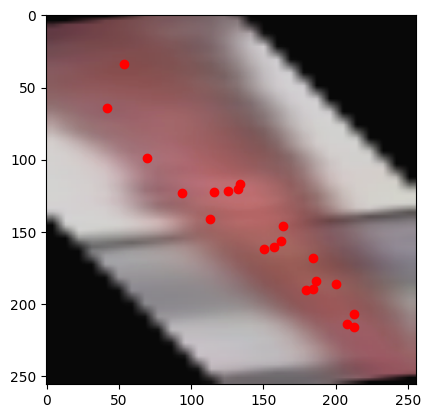

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

randomIndex = random.randint(0, len(testDataset) - 1)
img_tensor, label_tensor = testDataset[randomIndex]
# print(label_tensor)

img = img_tensor.permute(1, 2, 0).numpy() 

fig, ax = plt.subplots(1)
ax.imshow(img)

h, w, _ = img.shape

for keypoint in range(0, len(label_tensor), 3):  # FĂRĂ "- 8"
    x, y = label_tensor[keypoint], label_tensor[keypoint + 1]
    ax.plot(x * w, y * h, 'ro')

# bbox = label_tensor[-8:].view(4, 2).clone()
# bbox[:, 0] *= w
# bbox[:, 1] *= h

# poly = patches.Polygon(
#     bbox.detach().cpu().numpy(),
#     closed=True,
#     linewidth=2,
#     edgecolor='r',
#     facecolor='none'
# )
# print(f"bbox corners: {bbox.tolist()}")
# ax.add_patch(poly)


plt.show()

In [16]:
from torch.utils.data import DataLoader

batchSize = 4

def collate_fn(batch):
    return tuple(zip(*batch))

trainLoader = DataLoader(trainDataset, batch_size=batchSize, shuffle=True, collate_fn=collate_fn)
testLoader = DataLoader(testDataset, batch_size=batchSize, shuffle=False, collate_fn=collate_fn)

In [17]:
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))


def evaluate_model(net: nn.Module, test_loader: DataLoader, loss_fn: nn.Module):
    net.eval() 
    total_loss = 0.0
    batches = 0

    with torch.no_grad():
        for test_images, test_labels in test_loader:

            test_images = torch.stack(test_images).to(device)

            test_labels = [l.to(device) for l in test_labels]

            with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
                out = net(test_images)
                loss = loss_fn(out, test_labels)

            total_loss += loss.item()
            batches += 1

    
    return total_loss / batches if batches > 0 else 0


def train_fn(epochs: int, train_loader: DataLoader, test_loader: DataLoader,
             net: nn.Module, loss_fn: nn.Module, optimizer: optim.Optimizer,
             start_epoch: int = 0, wait_epochs: int = 5):
    bestValLoss = float('inf')
    lazy = 0
    last_val_loss = 0

    for e in range(start_epoch, epochs):
        net.train() 
        train_loss_acumulat = 0.0

        for images, labels in train_loader:
            
            images = torch.stack(images).to(device)
            labels = [l.to(device) for l in labels]

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
                out = net(images)
                loss = loss_fn(out, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss_acumulat += loss.item()

        avg_train_loss = train_loss_acumulat / len(train_loader)
        val_loss = evaluate_model(net, test_loader, loss_fn)

        if val_loss < bestValLoss:
            bestValLoss = val_loss
            torch.save(net.state_dict(), f'keypoints_epoch{e + 1}.pth')
            lazy = 0
        else:
            lazy += 1
            if lazy >= wait_epochs:
                # reduce learning rate by half
                for pg in optimizer.param_groups:
                    pg['lr'] = pg.get('lr', 0) * 0.5
                print(f"Reducing learning rate by 2 la epoca {e + 1}. New LR: {optimizer.param_groups[0]['lr']:.6f}")
                lazy = 0

        # if abs(val_loss - last_val_loss) <= 0.003:
        #     # reduce learning rate by half
        #     lazy += 1
            
        #     if lazy >= wait_epochs:
        #         for pg in optimizer.param_groups:
        #             pg['lr'] = pg.get('lr', 0) * 0.5
        #         print(f"Reducing learning rate by 2 la epoca {e + 1} din cauza stagnarii. New LR: {optimizer.param_groups[0]['lr']:.6f}")
        #         lazy = 0
        # else:
        #     lazy = 0
        # last_val_loss = val_loss

        print(f"Epoca {e + 1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Validation Loss: {val_loss:.4f}")



In [18]:
import importlib
import keypoints as keypoints_module
importlib.reload(keypoints_module)
from keypoints import HandKeypointDetector, IoULossHeatmap
import os

model = HandKeypointDetector().to(device)

checkpoint_path = "keypoints_epoch24.pth"
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
    print(f"Loaded checkpoint: {checkpoint_path}")
else:
    print(f"Checkpoint not found: {checkpoint_path}. Using randomly initialized weights.")

loss_fn = IoULossHeatmap(21)

optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

Loaded checkpoint: keypoints_epoch24.pth


In [19]:
import torch
print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print(f"Total Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GiB")
print(f"Available Memory: {torch.cuda.mem_get_info(0)[0] / 1e9:.2f} GiB")

# Check if memory is being cached/reserved
torch.cuda.empty_cache()
print(f"After cache clear: {torch.cuda.mem_get_info(0)[0] / 1e9:.2f} GiB")

GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU
Total Memory: 3.95 GiB
Available Memory: 3.76 GiB
After cache clear: 3.79 GiB


In [14]:

print("Incepem antrenamentul...")
train_fn(epochs=100, 
            train_loader=trainLoader, 
            test_loader=testLoader, 
            net=model, 
            loss_fn=loss_fn, 
            optimizer=optimizer)

Incepem antrenamentul...
Epoca 1/100 | Train Loss: 0.8495 | Validation Loss: 0.6636
Epoca 2/100 | Train Loss: 0.6028 | Validation Loss: 0.5654
Epoca 3/100 | Train Loss: 0.5438 | Validation Loss: 0.5379
Epoca 4/100 | Train Loss: 0.5147 | Validation Loss: 0.5080
Epoca 5/100 | Train Loss: 0.4958 | Validation Loss: 0.4895
Epoca 6/100 | Train Loss: 0.4816 | Validation Loss: 0.4781
Epoca 7/100 | Train Loss: 0.4707 | Validation Loss: 0.4772
Epoca 8/100 | Train Loss: 0.4614 | Validation Loss: 0.4666
Epoca 9/100 | Train Loss: 0.4539 | Validation Loss: 0.4629
Epoca 10/100 | Train Loss: 0.4473 | Validation Loss: 0.4550
Epoca 11/100 | Train Loss: 0.4419 | Validation Loss: 0.4416
Epoca 12/100 | Train Loss: 0.4367 | Validation Loss: 0.4376
Epoca 13/100 | Train Loss: 0.4318 | Validation Loss: 0.4365
Epoca 14/100 | Train Loss: 0.4278 | Validation Loss: 0.4344
Epoca 15/100 | Train Loss: 0.4238 | Validation Loss: 0.4287
Epoca 16/100 | Train Loss: 0.4197 | Validation Loss: 0.4225
Epoca 17/100 | Train Los

KeyboardInterrupt: 

In [20]:

print("Incepem antrenamentul...")
train_fn(epochs=100, 
            train_loader=trainLoader, 
            test_loader=testLoader, 
            net=model, 
            loss_fn=loss_fn, 
            optimizer=optimizer,
            start_epoch=25,)

Incepem antrenamentul...
Epoca 26/100 | Train Loss: 0.3967 | Validation Loss: 0.4032
Epoca 27/100 | Train Loss: 0.3941 | Validation Loss: 0.4027
Epoca 28/100 | Train Loss: 0.3923 | Validation Loss: 0.4030
Epoca 29/100 | Train Loss: 0.3909 | Validation Loss: 0.4027
Epoca 30/100 | Train Loss: 0.3885 | Validation Loss: 0.3971
Epoca 31/100 | Train Loss: 0.3875 | Validation Loss: 0.4012
Epoca 32/100 | Train Loss: 0.3849 | Validation Loss: 0.3959
Epoca 33/100 | Train Loss: 0.3835 | Validation Loss: 0.3923
Epoca 34/100 | Train Loss: 0.3829 | Validation Loss: 0.3948
Epoca 35/100 | Train Loss: 0.3812 | Validation Loss: 0.3920
Epoca 36/100 | Train Loss: 0.3802 | Validation Loss: 0.3920


KeyboardInterrupt: 

In [21]:
import importlib
import keypoints as keypoints_module
importlib.reload(keypoints_module)
from keypoints import HandKeypointDetector, IoULossHeatmap
import os

model = HandKeypointDetector().to(device)

checkpoint_path = "keypoints_epoch35.pth"
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
    print(f"Loaded checkpoint: {checkpoint_path}")
else:
    print(f"Checkpoint not found: {checkpoint_path}. Using randomly initialized weights.")

loss_fn = IoULossHeatmap(21)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Loaded checkpoint: keypoints_epoch35.pth


In [22]:

print("Incepem antrenamentul...")
train_fn(epochs=100, 
            train_loader=trainLoader, 
            test_loader=testLoader, 
            net=model, 
            loss_fn=loss_fn, 
            optimizer=optimizer,
            start_epoch=36,)

Incepem antrenamentul...
Epoca 37/100 | Train Loss: 0.5191 | Validation Loss: 0.5021
Epoca 38/100 | Train Loss: 0.4753 | Validation Loss: 0.4725
Epoca 39/100 | Train Loss: 0.4546 | Validation Loss: 0.4597
Epoca 40/100 | Train Loss: 0.4405 | Validation Loss: 0.4454
Epoca 41/100 | Train Loss: 0.4304 | Validation Loss: 0.4359
Epoca 42/100 | Train Loss: 0.4216 | Validation Loss: 0.4302
Epoca 43/100 | Train Loss: 0.4148 | Validation Loss: 0.4277
Epoca 44/100 | Train Loss: 0.4087 | Validation Loss: 0.4247
Epoca 45/100 | Train Loss: 0.4041 | Validation Loss: 0.4217
Epoca 46/100 | Train Loss: 0.3993 | Validation Loss: 0.4143
Epoca 47/100 | Train Loss: 0.3954 | Validation Loss: 0.4106
Epoca 48/100 | Train Loss: 0.3911 | Validation Loss: 0.4037
Epoca 49/100 | Train Loss: 0.3879 | Validation Loss: 0.3981
Epoca 50/100 | Train Loss: 0.3853 | Validation Loss: 0.3997
Epoca 51/100 | Train Loss: 0.3822 | Validation Loss: 0.4004
Epoca 52/100 | Train Loss: 0.3795 | Validation Loss: 0.3965
Epoca 53/100 | 

KeyboardInterrupt: 

# Test model

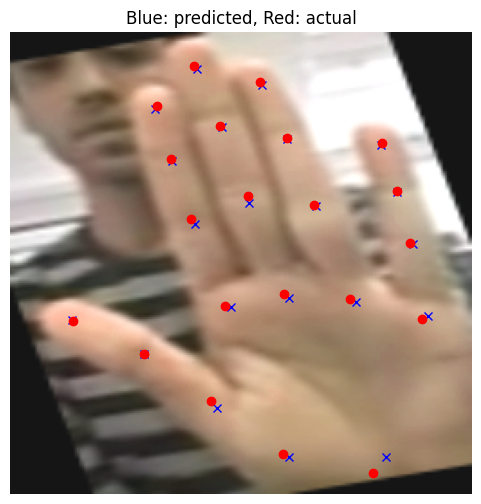

In [41]:
import matplotlib.pyplot as plt

randomIndex = random.randint(0, len(testDataset) - 1)
img_tensor, label_tensor = testDataset[randomIndex]

pred = model(img_tensor.unsqueeze(0).to(device))

img = img_tensor.permute(1, 2, 0).cpu().numpy()
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img)
h, w, _ = img.shape

# Predicted keypoints from heatmaps (argmax)
hmaps = pred.squeeze(0).cpu()  # (num_kp, Hm, Wm)
num_kp, Hm, Wm = hmaps.shape
for i in range(num_kp):
    hm = hmaps[i].detach().numpy()
    idx = hm.argmax()
    ym = idx // Wm
    xm = idx % Wm
    x_norm = xm / Wm
    y_norm = ym / Hm
    ax.plot(x_norm * w, y_norm * h, 'bx', markersize=6)

# Actual keypoints from label_tensor (x,y,vis triplets)
for k in range(0, len(label_tensor), 3):
    x = label_tensor[k].item()
    y = label_tensor[k + 1].item()
    ax.plot(x * w, y * h, 'ro', markersize=6)

ax.set_title("Blue: predicted, Red: actual")
plt.axis('off')
plt.show()